# 04 · Market risk and statistical tests

**Question.** How have the stocks performed and how risky were they, and how much of what the risk table shows is statistically distinguishable?

Return and risk functions come from `src/analytics/returns.py` and `risk.py`; test results are read from the stored Data Science Lab run.

*FinSight is an analytics tool, not investment advice.*

## 1. Data

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sqlalchemy import text

from src.database import queries
from src.database.connection import get_engine
from src.formatting import format_crore, format_metric, format_pct

pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 30)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "font.size": 9})
ACCENT, GREY = "#1f4e79", "#8c8c8c"

with get_engine().connect() as conn:
    companies = queries.load_companies(conn)
    metrics = queries.load_metrics(conn)
    statements = queries.load_statements(conn)
    prices = queries.load_prices(conn)
    as_of = queries.load_latest_price_date(conn).iloc[0]["latest"]
firms = companies[companies["entity_type"] == "company"].reset_index(drop=True)
short = lambda t: t.replace(".NS", "")
print(f"{len(firms)} companies in {firms['sector_name'].nunique()} sectors | "
      f"{len(metrics):,} stored metric rows | prices to {as_of}")

from src.analytics.peer_analytics import aligned_returns
from config.settings import get_universe

universe = get_universe()
returns = aligned_returns(prices)
BENCH = universe.benchmark.ticker
with get_engine().connect() as conn:
    tests = pd.read_sql(text("SELECT * FROM core.ml_stat_tests"), conn)
    summary = conn.execute(text(
        "SELECT results->'summary' FROM core.ml_runs WHERE task = 'stats_tests'")).scalar()
print(f"{len(returns):,} aligned return days, {returns.index[0].date()} to "
      f"{returns.index[-1].date()}; risk-free rate {universe.risk_free_rate.value:.4%}")

25 companies in 5 sectors | 6,146 stored metric rows | prices to 2026-10-06
1,221 aligned return days, 2021-10-07 to 2026-10-05; risk-free rate 5.2599%


## 2. Method

- Returns on adjusted close; placeholder rows excluded.
- Volatility = sample standard deviation × √252; Sharpe = (mean × 252 − Rf) ÷ volatility; downside deviation = RMS of returns below 0% over all days × √252; maximum drawdown from the running peak.
- Tests: Jarque–Bera, block-bootstrap intervals, Kruskal–Wallis with effect sizes, Benjamini–Hochberg correction for multiple comparisons.

In [2]:
from src.analytics import returns as R, risk

rf = universe.risk_free_rate.value
rows = []
for ticker in returns.columns:
    r = returns[ticker]
    wealth = (1 + r).cumprod()
    dd = risk.max_drawdown(wealth)
    rows.append({"ticker": short(ticker), "ann. return": risk.annualized_return(r),
                 "volatility": risk.annualized_volatility(r),
                 "downside dev.": risk.downside_deviation(r),
                 "Sharpe": risk.sharpe_ratio(r, rf), "max drawdown": dd["max_drawdown"],
                 "peak": dd["peak_date"], "trough": dd["trough_date"]})
full = pd.DataFrame(rows).set_index("ticker")
print("Full aligned history (the stored metrics use trailing 1- and 3-year windows):")
full.round(3)

Full aligned history (the stored metrics use trailing 1- and 3-year windows):


,ann. return,volatility,downside dev.,Sharpe,max drawdown,peak,trough
ticker,,,,,,,
ASIANPAINT,-0.028,0.222,0.162,-0.363,-0.397,2023-07-24,2026-03-23
AXISBANK,0.115,0.244,0.169,0.256,-0.280,2024-07-12,2025-01-27
BAJAJ-AUTO,0.238,0.245,0.166,0.757,-0.441,2024-09-27,2025-04-07
BRITANNIA,0.067,0.204,0.141,0.069,-0.290,2024-10-01,2025-03-04
CIPLA,0.109,0.229,0.148,0.246,-0.285,2024-10-09,2026-04-02
DIVISLAB,0.166,0.268,0.183,0.423,-0.472,2021-10-14,2023-02-07
DRREDDY,0.054,0.217,0.149,0.008,-0.253,2021-10-14,2022-03-03
EICHERMOT,0.211,0.262,0.170,0.604,-0.279,2021-10-12,2022-03-08
HCLTECH,0.057,0.252,0.180,0.017,-0.451,2025-01-10,2026-07-01


## 3. Results

### 3.1 Performance by sector

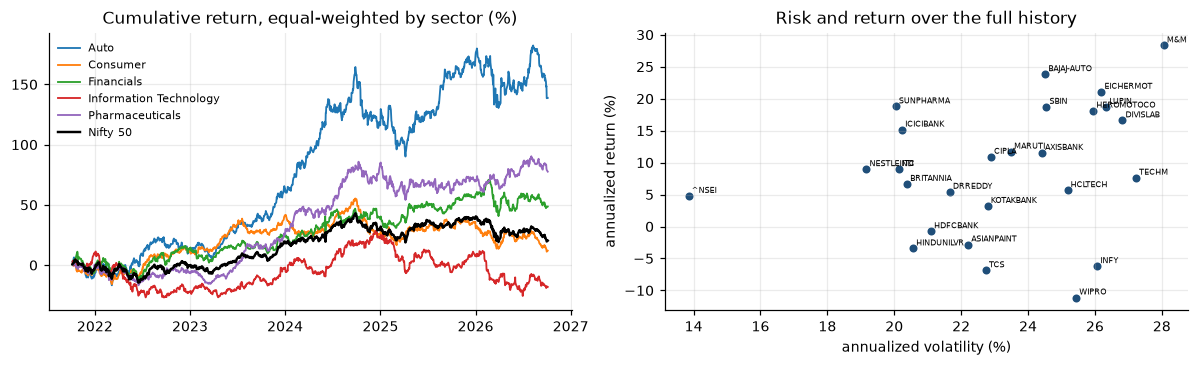

Nifty 50: volatility 13.8%, max drawdown -18.3%.
Stocks: volatility 19.2% to 28.1% (median 23.5%); max drawdown -20.3% to -57.1%.
Correlation of volatility with return across the 25 stocks: +0.28


In [3]:
sector = companies.set_index("ticker")["sector_name"]
cumulative = (1 + returns).cumprod() - 1
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
for name, group in sector.dropna().groupby(sector.dropna()):
    axes[0].plot(cumulative.index, cumulative[group.index].mean(axis=1) * 100, lw=1.2, label=name)
axes[0].plot(cumulative.index, cumulative[BENCH] * 100, color="black", lw=1.6, label="Nifty 50")
axes[0].set_title("Cumulative return, equal-weighted by sector (%)")
axes[0].legend(frameon=False, fontsize=7)
axes[1].scatter(full["volatility"] * 100, full["ann. return"] * 100, color=ACCENT, s=18)
for t, row in full.iterrows():
    axes[1].annotate(t, (row["volatility"] * 100, row["ann. return"] * 100), fontsize=5.5,
                     xytext=(2, 2), textcoords="offset points")
axes[1].set_xlabel("annualized volatility (%)"); axes[1].set_ylabel("annualized return (%)")
axes[1].set_title("Risk and return over the full history")
plt.tight_layout(); plt.show()
stocks = full.drop(index=short(BENCH))
print(f"Nifty 50: volatility {full.at[short(BENCH), 'volatility']:.1%}, max drawdown "
      f"{full.at[short(BENCH), 'max drawdown']:.1%}.")
print(f"Stocks: volatility {stocks['volatility'].min():.1%} to {stocks['volatility'].max():.1%} "
      f"(median {stocks['volatility'].median():.1%}); max drawdown "
      f"{stocks['max drawdown'].max():.1%} to {stocks['max drawdown'].min():.1%}.")
print(f"Correlation of volatility with return across the 25 stocks: "
      f"{stocks['volatility'].corr(stocks['ann. return']):+.2f}")

### 3.2 Is any Sharpe ratio distinguishable from zero?

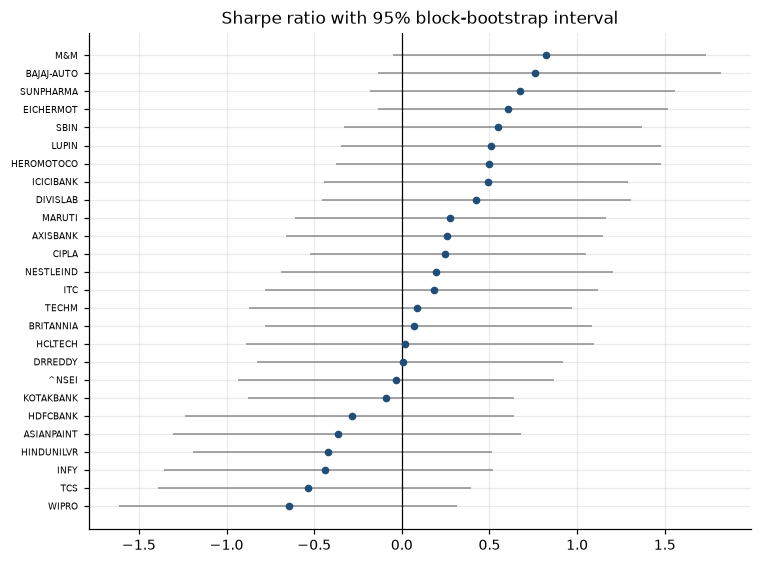

Intervals excluding zero: 0 of 26. Median interval width: 1.81.
The whole range of point estimates across tickers is 1.47 wide, about the width of a single ticker's interval.


In [4]:
sharpe = tests[tests["test"] == "sharpe_bootstrap_ci"].sort_values("statistic")
fig, ax = plt.subplots(figsize=(7, 5.2))
y = np.arange(len(sharpe))
ax.errorbar(sharpe["statistic"], y, xerr=[sharpe["statistic"] - sharpe["ci_low"],
                                          sharpe["ci_high"] - sharpe["statistic"]],
            fmt="o", color=ACCENT, ecolor=GREY, elinewidth=1, ms=4)
ax.axvline(0, color="black", lw=0.8)
ax.set_yticks(y, [short(s) for s in sharpe["subject"]], fontsize=6)
ax.set_title("Sharpe ratio with 95% block-bootstrap interval"); plt.tight_layout(); plt.show()
s = summary["sharpe"]
print(f"Intervals excluding zero: {s['intervals_excluding_zero']} of {s['series']}. Median "
      f"interval width: {s['median_interval_width']:.2f}.")
spread = sharpe["statistic"].max() - sharpe["statistic"].min()
print(f"The whole range of point estimates across tickers is {spread:.2f} wide, about the "
      "width of a single ticker's interval.")

### 3.3 Normality, sector differences, and correlation under stress

In [5]:
n = summary["normality"]
print(f"Normality (Jarque-Bera, BH-corrected): rejected for {n['rejected_at_5pct_after_bh']} of "
      f"{n['series_tested']} series. Excess kurtosis {n['excess_kurtosis_min']:.2f} to "
      f"{n['excess_kurtosis_max']:.2f}; {n['mean_share_beyond_3_sd']:.2%} of days beyond 3 sd "
      "(0.27% if normal).")
print("\nSector differences (Kruskal-Wallis):")
print(pd.DataFrame(summary["sector_differences"]).T[
    ["h_statistic", "p_value", "epsilon_squared", "pairs_significant_after_bh",
     "pairs_tested"]].round(4).to_string())
c = summary["correlation"]
print(f"\nCorrelations: {c['significant_after_bh']} of {c['pairs']} pairs significant after "
      f"correction; values from {c['min']:.2f} to {c['max']:.2f} (median {c['median']:.2f}).")
st = summary["stress_correlation"]
print(f"Stress: mean pairwise correlation {st['stressed']:.3f} on the {int(st['stressed_days'])} "
      f"highest-volatility days vs {st['calm']:.3f} on the other {int(st['calm_days'])}; "
      f"difference {st['difference']:+.3f} (95% CI {st['ci_low']:+.3f} to {st['ci_high']:+.3f}).")

Normality (Jarque-Bera, BH-corrected): rejected for 26 of 26 series. Excess kurtosis 1.16 to 8.13; 1.23% of days beyond 3 sd (0.27% if normal).

Sector differences (Kruskal-Wallis):
               h_statistic  p_value  epsilon_squared  pairs_significant_after_bh  pairs_tested
roe                14.0825   0.0070           0.5868                         0.0          10.0
net_margin         10.4492   0.0335           0.4354                         0.0          10.0
volatility_3y      15.2788   0.0042           0.6366                         2.0          10.0

Correlations: 300 of 300 pairs significant after correction; values from 0.09 to 0.73 (median 0.21).
Stress: mean pairwise correlation 0.352 on the 300 highest-volatility days vs 0.198 on the other 900; difference +0.154 (95% CI +0.093 to +0.213).


## 4. Interpretation

- The risk table ranks stocks by volatility with reasonable confidence: volatility is estimated precisely from daily data and differs clearly by sector.
- It does **not** rank them by risk-adjusted return. Every Sharpe interval includes zero and the intervals are about as wide as the spread between the best and worst estimate, so differences between Sharpe ratios here are not established.
- Returns are fat-tailed, so volatility understates how often large moves happen; the drawdown column is the more direct picture of the bad outcomes that occurred.
- Correlations are all positive and all significant, which with this many observations says only that they are not zero. Their size, and the fact that they rise when the market is volatile, is what matters for diversification.

## 5. Limitations

- About five years, one market, 25 large companies listed today.
- A single constant risk-free rate (5.2599%, September 2026) is applied to the whole period.
- Sector tests compare five companies with five: only large differences can reach significance, and a non-significant result is not evidence of no difference.
- The stress threshold uses the whole sample, so it describes the past.
- Bootstrap intervals depend on the block length (21 days here).

*FinSight is an analytics tool, not investment advice.*